# Lunar Lander - Reinforce Learning & Deep Q

In [81]:
import time
from collections import deque, namedtuple

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor

import numpy as np
from typing import Tuple
from PIL import Image
import utils
import pandas as pd

import random
SEED = 0
random.seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"当前使用的设备是：{device}")

# # Set up a virtual display to render the Lunar Lander environment.
# import os
# from pyvirtualdisplay import Display

# os.environ['DISPLAY'] = ':99' 
# disp = Display(visible=0, size=(840, 480), backend="xvfb")
# disp.start()


当前使用的设备是：mps


In [82]:
import gymnasium as gym
import matplotlib.pyplot as plt

# 1. 指定渲染模式为 'rgb_array'，彻底避开底层图形界面的依赖
env = gym.make('CartPole-v1', render_mode='rgb_array')
observation, info = env.reset()

# 2. 准备 matplotlib 的动态绘图窗口
def test_renderer():
    plt.ion()  # 开启交互模式
    fig, ax = plt.subplots()
    # 初始化一个空的图像占位符
    img_plot = ax.imshow(env.render())  
    plt.axis('off')  # 关闭坐标轴，只看画面
    plt.title("Gymnasium Native Rendering (No Xvfb)")

    try:
        while True:
            action = env.action_space.sample() # 随机动作
            observation, reward, terminated, truncated, info = env.step(action)
            
            # 3. 获取当前帧的 RGB 数组并更新到 matplotlib 窗口中
            frame = env.render()
            img_plot.set_data(frame)
            plt.pause(0.01) # 暂停一小段时间，形成动画效果
            
            # 如果回合结束，重置环境
            if terminated or truncated:
                observation, info = env.reset()
                
    except KeyboardInterrupt:
        print("\n手动退出渲染。")
    finally:
        env.close()
        plt.close()

In [83]:
MEMORY_SIZE = 100_000     # size of memory buffer
GAMMA = 0.995             # discount factor
ALPHA = 1e-3              # learning rate  
NUM_STEPS_FOR_UPDATE = 4  # perform a learning update every C time steps
MINIBATCH_SIZE = 64   # mini-batch size
TAU = 1e-3            # soft update parameter
E_DECAY = 0.995       # ε decay rate for ε-greedy policy
E_MIN = 0.01          # minimum ε value for ε-greedy policy


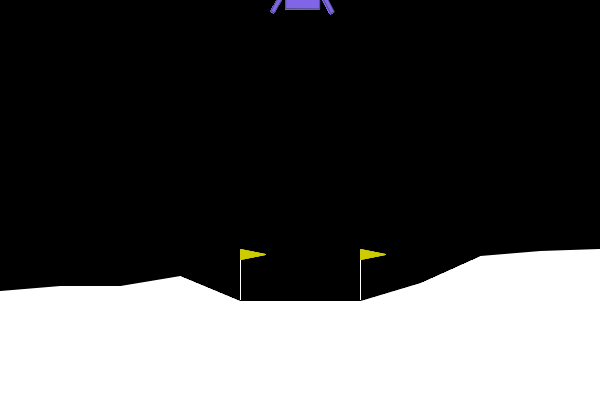

In [84]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")
env.reset()
img_array = env.render()
img = Image.fromarray(img_array)
img

In [85]:
state_size = env.observation_space.shape
num_actions = env.action_space.n

print('State Shape:', state_size)
print('Number of actions:', num_actions)
print(f'env.observation_space: {env.observation_space}')
print(f'env.action_space: {env.action_space}')

State Shape: (8,)
Number of actions: 4
env.observation_space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
env.action_space: Discrete(4)


In [86]:
initial_state = env.reset()

# Select an action
action = 0

# Run a single time step of the environment's dynamics with the given action.
next_state, reward, done, truncated, info = env.step(action)

with np.printoptions(formatter={'float': '{:.3f}'.format}):
    print("Initial State:", initial_state)
    print("Action:", action)
    print("Next State:", next_state)
    print("Reward Received:", reward)
    print("Episode Terminated:", done)
    print("Truncated:", truncated)
    print("Info:", info)

Initial State: (array([-0.001, 1.399, -0.058, -0.541, 0.001, 0.013, 0.000, 0.000],
      dtype=float32), {})
Action: 0
Next State: [-0.001 1.386 -0.058 -0.567 0.001 0.013 0.000 0.000]
Reward Received: -1.3374282428305833
Episode Terminated: False
Truncated: False
Info: {}


In [87]:
class LunarLanderModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()  # 必须写
        self.lander_nn = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, states) -> Tensor:
        v = self.lander_nn(states)
        
        return v

In [88]:
experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])

In [89]:
# V1
def compute_loss(experiences: Tuple, gamma: float, q_model, target_model) -> Tensor:
    
    states, actions, rewards, next_states, done_vals = experiences
    states = torch.as_tensor(states, dtype=torch.float32)
    actions = torch.as_tensor(actions, dtype=torch.long)
    rewards = torch.as_tensor(rewards, dtype=torch.float32)
    next_states = torch.as_tensor(next_states, dtype=torch.float32)
    done_vals = torch.as_tensor(done_vals, dtype=torch.float32)

    with torch.no_grad():
        target_tensor = target_model(next_states)
        target_max, _ = torch.max(target_tensor, axis=-1)
        y_targets = rewards + (gamma * target_max * (1 - done_vals))

    q_tensor = q_model(states)
    q_values = q_tensor.gather(dim=1, index=actions.unsqueeze(1))

    # 计算损失
    # loss = F.mse_loss(y_targets, q_values)
    loss = F.mse_loss(y_targets.unsqueeze(1), q_values)
    
    return loss

In [ ]:
TAU = 1e-3  
def update_target_network(q_network, target_q_network):
    with torch.no_grad():
        for target_param, q_param in zip(target_q_network.parameters(), q_network.parameters()):
            target_param.data.mul_(1.0 - TAU)
            target_param.data.add_(TAU * q_param.data)

def get_action(q_values, epsilon=0):
    if random.random() > epsilon:
        return np.argmax(q_values.detach().numpy()[0])
    else:
        return random.choice(np.arange(4))

q_network = LunarLanderModel(input_dim=8, output_dim=4)
target_q_network = LunarLanderModel(input_dim=8, output_dim=4)
optimizer_q = optim.Adam(q_network.parameters(), ALPHA)
q_network.to(device)
target_q_network.to(device)

def agent_learn(experiences, gamma):
    """
    Updates the weights of the Q networks.
    
    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
    
    """
    
    # Calculate the loss
    loss = compute_loss(experiences, gamma, q_network, target_q_network)
    optimizer_q.zero_grad()
    loss.backward()
    optimizer_q.step()
    update_target_network(q_network, target_q_network)

def check_update_conditions(t, num_steps_upd, memory_buffer):
    if (t + 1) % num_steps_upd == 0 and len(memory_buffer) > MINIBATCH_SIZE:
        return True
    else:
        return False

def get_experiences(memory_buffer):
    experiences = random.sample(memory_buffer, k=MINIBATCH_SIZE)
    states = torch.as_tensor(np.array([e.state for e in experiences if e is not None]),dtype=torch.float32)
    actions = torch.as_tensor(np.array([e.action for e in experiences if e is not None]), dtype=torch.float32)
    rewards = torch.as_tensor(np.array([e.reward for e in experiences if e is not None]), dtype=torch.float32)
    next_states = torch.as_tensor(np.array([e.next_state for e in experiences if e is not None]),dtype=torch.float32)
    done_vals = torch.as_tensor(np.array([e.done for e in experiences if e is not None]).astype(np.uint8),
                                     dtype=torch.float32)
    return (states, actions, rewards, next_states, done_vals)

def get_new_eps(epsilon):
    return max(E_MIN, E_DECAY*epsilon)



In [110]:
start = time.time()

num_episodes = 2000
max_num_timesteps = 1000

total_point_history = []

num_p_av = 100    # number of total points to use for averaging
epsilon = 1.0     # initial ε value for ε-greedy policy

# Create a memory buffer D with capacity N
memory_buffer = deque(maxlen=MEMORY_SIZE)

# Set the target network weights equal to the Q-Network weights
# target_q_network.set_weights(q_network.get_weights()) # TensorFlow
target_q_network.load_state_dict(q_network.state_dict())

for i in range(num_episodes):
    
    # Reset the environment to the initial state and get the initial state
    state, _ = env.reset()
    total_points = 0
    
    for t in range(max_num_timesteps):
        
        # From the current state S choose an action A using an ε-greedy policy
        state_qn = torch.as_tensor(np.expand_dims(state, axis=0), dtype=torch.float32)  
        q_values = q_network(state_qn)
        action = get_action(q_values, epsilon)
        
        # Take action A and receive reward R and the next state S'
        next_state, reward, done, _, _ = env.step(action)
        
        # Store experience tuple (S,A,R,S') in the memory buffer.
        # We store the done variable as well for convenience.
        memory_buffer.append(experience(state, action, reward, next_state, done))
        
        # Only update the network every NUM_STEPS_FOR_UPDATE time steps.
        update = check_update_conditions(t, NUM_STEPS_FOR_UPDATE, memory_buffer)
        
        if update:
            # Sample random mini-batch of experience tuples (S,A,R,S') from D
            experiences = get_experiences(memory_buffer)
            
            # Set the y targets, perform a gradient descent step,
            # and update the network weights.
            agent_learn(experiences, GAMMA)
        
        state = next_state.copy()
        total_points += reward
        
        if done:
            break
            
    total_point_history.append(total_points)
    av_latest_points = np.mean(total_point_history[-num_p_av:])
    
    # Update the ε value
    epsilon = get_new_eps(epsilon)

    print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}", end="")

    if (i+1) % num_p_av == 0:
        print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}")

    # We will consider that the environment is solved if we get an
    # average of 200 points in the last 100 episodes.
    if av_latest_points >= 200.0:
        print(f"\n\nEnvironment solved in {i+1} episodes!")
        # q_network.save('lunar_lander_model.h5')
        break
        
tot_time = time.time() - start

print(f"\nTotal Runtime: {tot_time:.2f} s ({(tot_time/60):.2f} min)")

Episode 100 | Total point average of the last 100 episodes: -100.68
Episode 200 | Total point average of the last 100 episodes: -24.196
Episode 300 | Total point average of the last 100 episodes: 43.342
Episode 400 | Total point average of the last 100 episodes: 163.06
Episode 461 | Total point average of the last 100 episodes: 200.36

Environment solved in 461 episodes!

Total Runtime: 84.28 s (1.40 min)


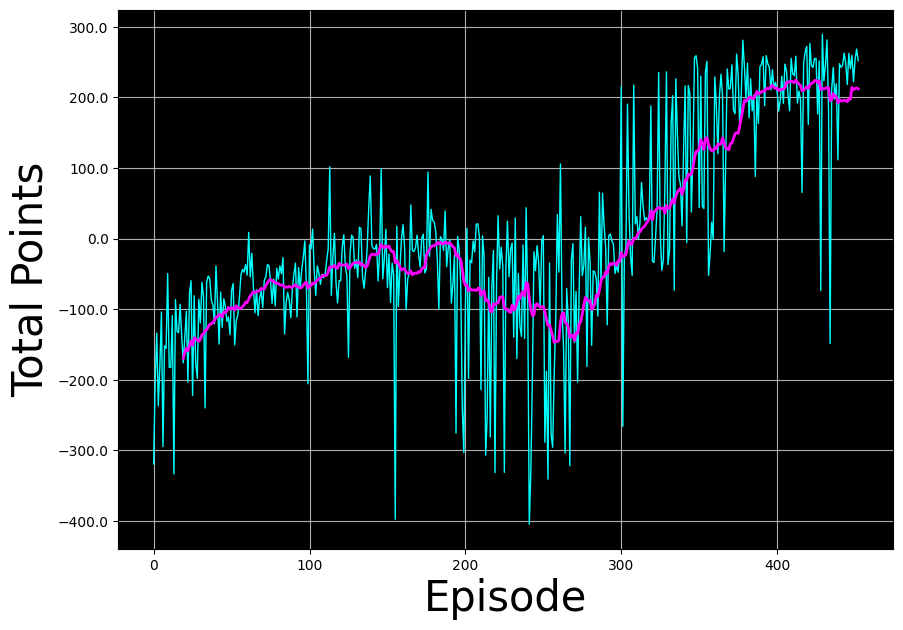

In [97]:
import matplotlib.ticker as mticker

def plot_history(reward_history, rolling_window=20, lower_limit=None,
                 upper_limit=None, plot_rw=True, plot_rm=True):
    
    if lower_limit is None or upper_limit is None:
        rh = reward_history
        xs = [x for x in range(len(reward_history))]
    else:
        rh = reward_history[lower_limit:upper_limit]
        xs = [x for x in range(lower_limit,upper_limit)]
    
    df = pd.DataFrame(rh)
    rollingMean = df.rolling(rolling_window).mean()

    plt.figure(figsize=(10,7), facecolor='white')
    
    if plot_rw:
        plt.plot(xs, rh, linewidth=1, color='cyan')
    if plot_rm:
        plt.plot(xs, rollingMean, linewidth=2, color='magenta')

    text_color = 'black'
        
    ax = plt.gca()
    ax.set_facecolor('black')
    plt.grid()
#     plt.title("Total Point History", color=text_color, fontsize=40)
    plt.xlabel('Episode', color=text_color, fontsize=30)
    plt.ylabel('Total Points', color=text_color, fontsize=30)
    yNumFmt = mticker.StrMethodFormatter('{x:,}')
    ax.yaxis.set_major_formatter(yNumFmt)
    ax.tick_params(axis='x', colors=text_color)
    ax.tick_params(axis='y', colors=text_color)
    plt.show()

plot_history(total_point_history)

In [98]:
# Suppress warnings from imageio
import logging
logging.getLogger().setLevel(logging.ERROR)

In [115]:
import imageio
import base64
import IPython


def embed_mp4(filename):
    """Embeds an mp4 file in the notebook."""
    video = open(filename,'rb').read()
    b64 = base64.b64encode(video)
    tag = '''
    <video width="840" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
    Your browser does not support the video tag.
    </video>'''.format(b64.decode())
    return IPython.display.HTML(tag)
        
        
def create_video(filename, env, q_network, fps=30):
    with imageio.get_writer(filename, fps=fps) as video:
        done = False
        state, _ = env.reset()
        frame = env.render()
        video.append_data(frame)
        while not done:    
            state = np.expand_dims(state, axis=0)
            q_values = q_network(torch.from_numpy(state).float())
            action = np.argmax(q_values.detach().numpy()[0])
            state, _, done, _ , _= env.step(action)
            frame = env.render()
            video.append_data(frame)

filename = "/Users/kcui/tmp/lunar_lander.mp4"

env.reset()
create_video(filename, env, q_network)
embed_mp4(filename)